# BrainScanAI — Notebook 1 : exploration, features et clustering

**Contexte.** CurelyticsIA veut savoir s'il est possible d'automatiser la détection de tumeurs cérébrales sur IRM. Sur 1 500 images, seules 100 ont été annotées par des radiologues (normal / cancer) ; le reste n'a aucune étiquette.

**Objectif de ce notebook :**
1. Explorer le jeu de données
2. Préparer les images et extraire des features avec un modèle pré-entraîné
3. Réduire la dimension, appliquer un clustering et produire des labels « faibles »

---

## Étape 1 — Exploration du jeu de données

Avant tout traitement, on vérifie ce qu'on a réellement entre les mains : nombre d'images, dimensions, canaux de couleur, qualité des fichiers. Chaque anomalie repérée ici peut fausser les étapes suivantes.

### 1.1 Imports et chemin des données

Tout le chemin vers les données tient dans une seule variable `DATA_DIR` : c'est la seule ligne à modifier si on exécute le notebook ailleurs (sur Colab par exemple).

In [1]:
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Dossier du dataset (à adapter si on travaille sur Colab)
DATA_DIR = Path("../mri_dataset_brain_cancer_oc")

### 1.2 Inventaire des images

On parcourt tous les fichiers `.jpg` et on range leurs informations dans un DataFrame. Le sous-ensemble (`avec_labels` / `sans_label`) et le label (`cancer` / `normal`) se déduisent directement de l'arborescence des dossiers.

In [2]:
rows = []
for path in sorted(DATA_DIR.rglob("*.jpg")):
    rel = path.relative_to(DATA_DIR)
    subset = rel.parts[0]                                      # "avec_labels" ou "sans_label"
    label = rel.parts[1] if subset == "avec_labels" else None  # "cancer" / "normal", ou rien
    rows.append({"path": path, "subset": subset, "label": label})

df = pd.DataFrame(rows)

# Colonne pratique pour les graphiques : cancer / normal / sans_label
df["groupe"] = df["label"].fillna("sans_label")

print(f"{len(df)} images au total")
df["groupe"].value_counts()

1506 images au total


groupe
sans_label    1406
cancer          50
normal          50
Name: count, dtype: int64

### 1.3 Propriétés techniques des images

Pour chaque image, on lit ses dimensions, son mode couleur (`L` = niveaux de gris, `RGB` = couleur) et le poids du fichier. La doc annonce des images 512×512 : on vérifie que c'est bien le cas partout.

In [3]:
def image_info(path):
    """Ouvre l'image et renvoie ses caractéristiques techniques."""
    with Image.open(path) as img:
        return {"width": img.width, "height": img.height, "mode": img.mode, "format": img.format}

infos = pd.DataFrame([image_info(p) for p in df["path"]])
df = pd.concat([df, infos], axis=1)
df["file_kb"] = df["path"].apply(lambda p: p.stat().st_size / 1024)

# Combinaisons dimensions / mode couleur / format rencontrées
df.groupby(["width", "height", "mode", "format"]).size().rename("nb_images")

width  height  mode  format
512    512     RGB   JPEG      1506
Name: nb_images, dtype: int64

In [4]:
# Distribution du poids des fichiers (en Ko) par groupe
df.groupby("groupe")["file_kb"].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
groupe,,,,,,,,
cancer,50.0,22.5,4.0,15.8,19.3,23.0,25.2,31.8
normal,50.0,29.1,11.4,17.4,23.0,25.3,29.4,64.3
sans_label,1406.0,24.1,5.8,13.1,20.6,23.2,26.6,73.7


### 1.4 Vraies couleurs ou niveaux de gris déguisés ?

Une IRM est par nature en niveaux de gris. Si les images sont stockées en RGB, les trois canaux devraient être (presque) identiques. On mesure pour chaque image l'écart maximal entre canaux : 0 = gris parfait. La compression JPEG peut créer de petits écarts, d'où un seuil de tolérance.

C'est important pour l'étape 2 : ResNet attend 3 canaux en entrée. Si les images sont grises, on dupliquera le canal gris.

In [5]:
def channel_diff(path):
    """Écart maximal entre les canaux R, G et B de l'image (0 = image grise)."""
    arr = np.asarray(Image.open(path).convert("RGB"), dtype=np.int16)
    return max(
        np.abs(arr[..., 0] - arr[..., 1]).max(),
        np.abs(arr[..., 1] - arr[..., 2]).max(),
    )

df["channel_diff"] = df["path"].apply(channel_diff)

TOLERANCE = 10  # écart toléré, lié à la compression JPEG
df["is_gray"] = df["channel_diff"] <= TOLERANCE

print(df["channel_diff"].describe().round(1))
df.groupby("groupe")["is_gray"].mean().rename("part_images_grises")

count    1506.0
mean        0.2
std         3.2
min         0.0
25%         0.0
50%         0.0
75%         0.0
max        81.0
Name: channel_diff, dtype: float64


groupe
cancer        1.00000
normal        1.00000
sans_label    0.99431
Name: part_images_grises, dtype: float64

### 1.5 Visualisation d'exemples

On affiche quelques images tirées au hasard dans chaque groupe. C'est l'étape la plus simple et souvent la plus instructive : cadrage, contraste, orientation, présence visible de la tumeur.

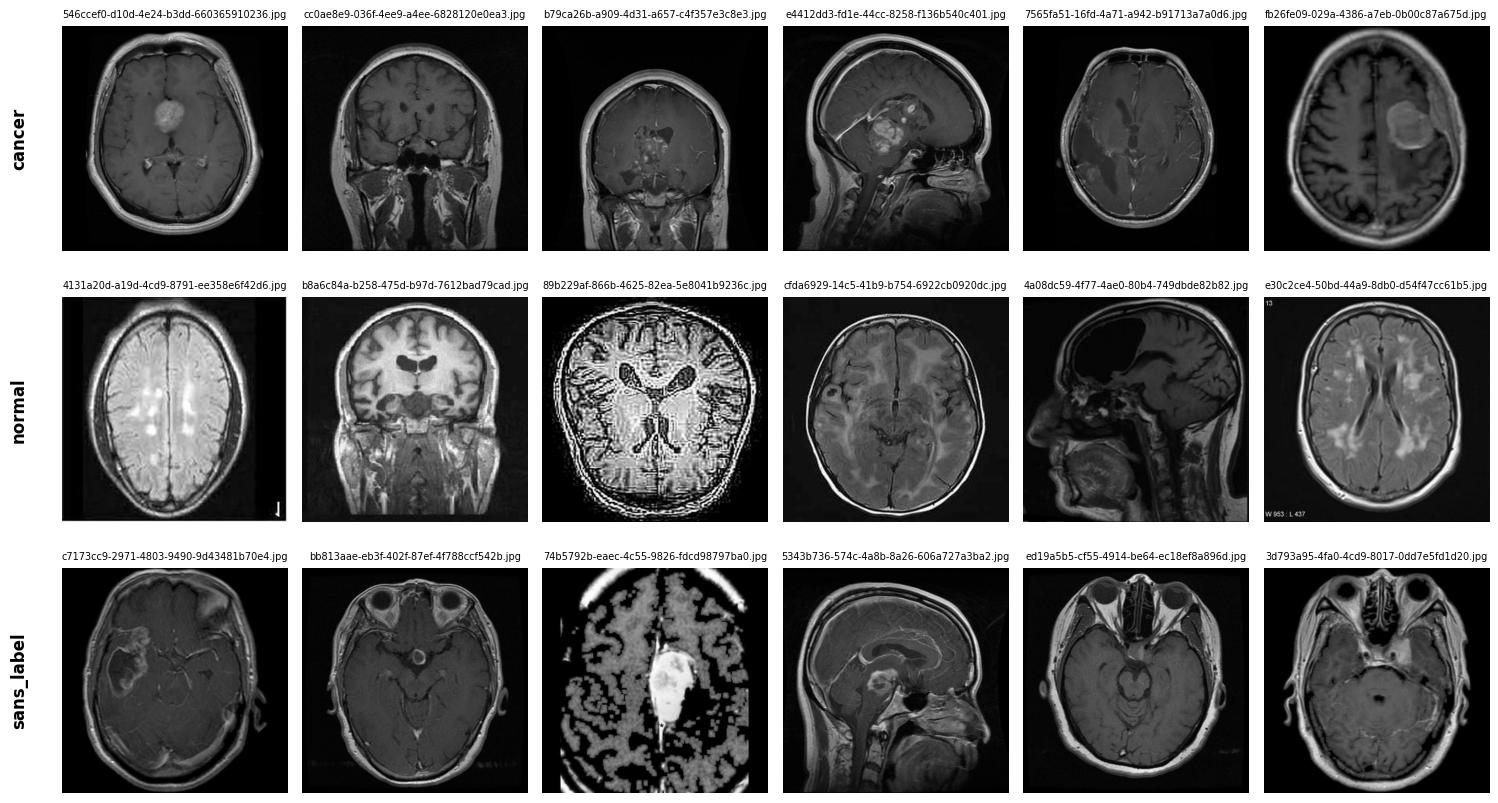

In [6]:
N_PER_ROW = 6
groupes = ["cancer", "normal", "sans_label"]

fig, axes = plt.subplots(len(groupes), N_PER_ROW, figsize=(2.5 * N_PER_ROW, 2.8 * len(groupes)))
for row, groupe in enumerate(groupes):
    # Tirage aléatoire reproductible (random_state fixé)
    sample = df[df["groupe"] == groupe].sample(N_PER_ROW, random_state=42)
    for col, path in enumerate(sample["path"]):
        ax = axes[row, col]
        ax.imshow(Image.open(path), cmap="gray")
        ax.set_title(path.name, fontsize=7)
        ax.axis("off")
    axes[row, 0].text(-0.15, 0.5, groupe, transform=axes[row, 0].transAxes,
                      rotation=90, va="center", ha="right", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### 1.6 Qualité : fichiers corrompus et doublons

Deux vérifications :
- **Fichiers corrompus** : `Image.verify()` contrôle l'intégrité de chaque fichier.
- **Doublons exacts** : on calcule une empreinte MD5 du contenu de chaque fichier. Deux fichiers avec la même empreinte sont strictement identiques. Cela pourrait expliquer les 1 406 images sans label, alors que la doc en annonce 1 400.

Point d'attention : un doublon **entre** `avec_labels` et `sans_label` serait une fuite de données, puisque la même image se retrouverait à la fois dans le jeu fort et dans le jeu faible.

In [7]:
def is_valid(path):
    """True si le fichier image est lisible et non corrompu."""
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False

df["is_valid"] = df["path"].apply(is_valid)
print(f"Fichiers corrompus : {(~df['is_valid']).sum()}")

# Empreinte MD5 du contenu de chaque fichier
df["md5"] = df["path"].apply(lambda p: hashlib.md5(p.read_bytes()).hexdigest())
dups = df[df.duplicated("md5", keep=False)].sort_values("md5")

print(f"Images impliquées dans un doublon : {len(dups)}")
print(f"Groupes de doublons : {dups['md5'].nunique()}")

# Doublons qui traversent plusieurs groupes (risque de fuite de données)
cross = dups.groupby("md5")["groupe"].nunique()
print(f"Groupes de doublons à cheval sur plusieurs groupes : {(cross > 1).sum()}")

dups[["md5", "groupe", "path"]].assign(path=dups["path"].apply(lambda p: p.name))

Fichiers corrompus : 0
Images impliquées dans un doublon : 186
Groupes de doublons : 90
Groupes de doublons à cheval sur plusieurs groupes : 31


,md5,groupe,path
651,038bd3a36c6463f3a9f18ac031ea1c4d,sans_label,63f74ae7-15f3-40e6-90f8-850dd20dbb70.jpg
988,038bd3a36c6463f3a9f18ac031ea1c4d,sans_label,a74cd797-2401-44e9-b29b-e3e125c8e148.jpg
1086,0652cb55477c4edeea5c5dfd53944e3b,sans_label,b65c7ebe-aac9-414e-a9d3-b8205d5d5a23.jpg
97,0652cb55477c4edeea5c5dfd53944e3b,normal,defdbef3-bea2-4f32-9d9a-62af1102ebfd.jpg
369,0816537db58c1d8092808f2c6f75e96c,sans_label,2f0c7977-339e-4e46-b412-c8fd1a8d05b0.jpg
...,...,...,...
51,fa2f6066ee4f4e22f35c46c4ddf8584b,normal,09316c60-86c8-4f24-934e-8d433b8b9d72.jpg
187,fdc753e2225fcf328308438eb4f37058,sans_label,0e6c3f73-189a-420c-b17e-17dd19ac7736.jpg
579,fdc753e2225fcf328308438eb4f37058,sans_label,592e9fb8-cf27-4acf-ab1f-7644e76ff88e.jpg
1074,fe822536fc06483aeea76f22e3709f50,sans_label,b3d19755-4df5-4a8a-9206-92f244ea82bc.jpg


### 1.7 Traitement des doublons

Les 1 506 fichiers ne correspondent qu'à environ 1 410 images réellement différentes. On distingue trois cas, qui n'ont pas la même gravité :

| Cas | Conséquence si on ne fait rien |
| --- | --- |
| Plusieurs copies d'une même image dans `sans_label` | Certaines images pèsent 2 ou 3 fois plus que les autres dans le clustering et dans l'entraînement : un biais léger. |
| Deux copies d'une même image dans `normal` | On croit avoir 50 images normales alors qu'on n'en a que 49. |
| **Une image labellisée dont une copie se trouve dans `sans_label`** | **Fuite de données.** La copie recevrait un label faible et servirait à l'entraînement, alors que l'original peut finir dans le jeu de test fort. Le modèle serait évalué sur des images qu'il a déjà vues, et les scores du semi-supervisé seraient artificiellement gonflés. |

**Règle appliquée :** on ne garde qu'**une seule copie** de chaque image (identifiée par son empreinte MD5). Quand une image existe à la fois avec et sans label, c'est la **version labellisée qui est conservée** : l'étiquette d'un radiologue vaut plus qu'une étiquette faible, et on retire ainsi toute trace des images labellisées dans `sans_label`.

Les fichiers d'origine ne sont pas modifiés : on travaille sur un DataFrame nettoyé, `df_clean`, qui servira de référence pour toute la suite du projet.

In [8]:
# Priorité : une copie labellisée (0) passe avant une copie sans label (1)
priority = {"cancer": 0, "normal": 0, "sans_label": 1}

df_clean = (
    df.assign(prio=df["groupe"].map(priority))
      .sort_values(["prio", "path"])            # les copies labellisées passent en premier
      .drop_duplicates("md5", keep="first")     # on garde la première copie de chaque image
      .drop(columns="prio")
      .sort_index()
      .reset_index(drop=True)
)

# Vérification : plus aucune empreinte partagée entre images labellisées et non labellisées
md5_labels = set(df_clean.loc[df_clean["subset"] == "avec_labels", "md5"])
md5_sans_label = set(df_clean.loc[df_clean["subset"] == "sans_label", "md5"])
assert md5_labels.isdisjoint(md5_sans_label), "Fuite : une image labellisée est encore dans sans_label"

pd.DataFrame({
    "avant": df["groupe"].value_counts(),
    "après": df_clean["groupe"].value_counts(),
}).assign(retirées=lambda t: t["avant"] - t["après"])

,avant,après,retirées
groupe,,,
sans_label,1406,1311,95
cancer,50,50,0
normal,50,49,1


On sauvegarde l'inventaire nettoyé en CSV. Les chemins y sont stockés **relativement à `DATA_DIR`**, pour que le fichier reste utilisable si le dataset est placé ailleurs (sur Colab par exemple).

In [9]:
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

inventaire = df_clean[["path", "subset", "label", "groupe", "md5"]].copy()
inventaire["path"] = inventaire["path"].apply(lambda p: p.relative_to(DATA_DIR).as_posix())
inventaire.to_csv(OUTPUT_DIR / "inventaire_images.csv", index=False)

print(f"{len(inventaire)} images sauvegardées dans {OUTPUT_DIR / 'inventaire_images.csv'}")

1410 images sauvegardées dans ../outputs/inventaire_images.csv


### 1.8 Intensité des images

On calcule la luminosité moyenne de chaque image (moyenne des pixels en niveaux de gris, entre 0 et 255) et on compare les groupes, sur le jeu dédoublonné. Un écart marqué entre `cancer` et `normal` serait un signal à surveiller : le modèle pourrait apprendre à reconnaître la luminosité plutôt que la tumeur.

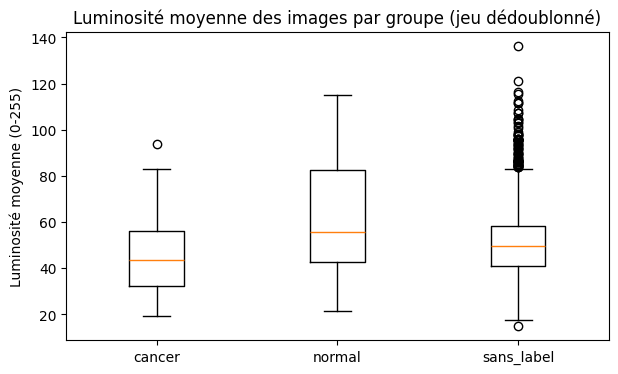

,count,mean,std,min,25%,50%,75%,max
groupe,,,,,,,,
cancer,50.0,46.0,15.5,19.5,32.5,43.6,56.2,94.0
normal,49.0,62.0,23.8,21.5,42.7,55.6,82.4,115.2
sans_label,1311.0,51.6,16.6,14.9,41.2,49.9,58.1,136.2


In [10]:
df_clean["mean_intensity"] = df_clean["path"].apply(lambda p: np.asarray(Image.open(p).convert("L")).mean())

fig, ax = plt.subplots(figsize=(7, 4))
data = [df_clean.loc[df_clean["groupe"] == g, "mean_intensity"] for g in groupes]
ax.boxplot(data, tick_labels=groupes)
ax.set_ylabel("Luminosité moyenne (0-255)")
ax.set_title("Luminosité moyenne des images par groupe (jeu dédoublonné)")
plt.show()

df_clean.groupby("groupe")["mean_intensity"].describe().round(1)

### 1.9 Observations

**Volume et format**
- 1 506 fichiers, mais seulement **1 410 images uniques** après dédoublonnage : **50 cancer, 49 normal, 1 311 sans label**. Les doublons expliquent l'écart avec la documentation, qui annonce 1 400 images sans label.
- Les images sont en **JPEG**, pas en PNG comme l'annonçait le mail de Clara.
- Format homogène : toutes les images font 512×512 pixels et aucun fichier n'est corrompu.

**Couleur**
- Toutes les images sont stockées en RGB, mais ce sont en réalité des **niveaux de gris** (canaux R, G et B identiques).
- 8 images sans label contiennent un peu de couleur : des bandeaux ou des textes bleus en bas de l'image, sur 0,01 % à 5,5 % des pixels. Ce sont probablement des captures d'écran de visionneuse. L'image médicale elle-même reste grise.
- Conséquence pour l'étape 2 : on convertit tout en niveaux de gris, puis on duplique ce canal sur 3 canaux, puisque ResNet attend une image RGB.

**Doublons**
- 96 fichiers retirés : 64 copies en trop dans `sans_label`, 1 dans `normal`, et surtout **31 images labellisées qui avaient une copie dans `sans_label`**. Sans ce nettoyage, ces copies auraient provoqué une fuite de données entre le jeu faible et le jeu de test fort.
- Limite : l'empreinte MD5 ne détecte que les copies **strictement identiques**. Des quasi-doublons (image recadrée ou recompressée) peuvent subsister. On pourra les repérer à l'étape 2 en comparant les embeddings.

**Hétérogénéité des images**
- Les IRM mélangent plusieurs **plans de coupe** (axial, coronal, sagittal) et plusieurs **séquences** d'acquisition (le contraste change d'une image à l'autre).
- Certaines images portent des annotations incrustées : textes, repères, valeurs de fenêtrage.
- Les images `cancer` semblent surtout acquises avec la même séquence, sur fond sombre, alors que les images `normal` sont plus variées et **plus claires** : leur luminosité médiane est de 55,6, contre 43,6 pour `cancer`.

**Point de vigilance pour la suite**
- Ce déséquilibre de séquences entre `cancer` et `normal` est un **biais potentiel**. À l'étape 3, le clustering pourrait séparer les images selon le type de séquence ou de plan de coupe plutôt que selon la présence d'une tumeur. Il faudra le garder en tête au moment d'interpréter l'ARI.
- Avec seulement 99 images labellisées, le jeu de test sera petit, et les métriques varieront sensiblement d'un découpage à l'autre.

---

## Étape 2 — Preprocessing et extraction des embeddings

On utilise un **ResNet50 pré-entraîné sur ImageNet**, entièrement gelé, comme extracteur de caractéristiques. Chaque IRM est transformée en un vecteur numérique (un *embedding*) qui résume son contenu visuel. Ce sont ces vecteurs, et non les pixels, qui serviront au clustering de l'étape 3.

### 2.1 Preprocessing

Le réseau a été entraîné sur des images présentées d'une certaine façon : il faut lui fournir les nôtres dans le même format.

| Transformation | Pourquoi |
| --- | --- |
| Niveaux de gris dupliqués sur 3 canaux | ResNet attend 3 canaux (RGB). Nos images sont grises : on recopie le canal gris 3 fois. Cela efface au passage les bandeaux bleus des 8 captures d'écran. |
| Redimensionnement 512 → 224 px | Taille d'entrée standard de ResNet. On redimensionne **sans recadrer** : un recadrage central risquerait de couper une tumeur située en bord de cerveau. |
| Conversion en tenseur | Passage des pixels de [0, 255] à [0, 1], au format (canaux, hauteur, largeur) attendu par PyTorch. |
| Normalisation ImageNet | On centre et on réduit chaque canal avec la moyenne et l'écart-type des images d'ImageNet, la distribution sur laquelle le réseau a appris. |

In [11]:
import torch
from torchvision import models, transforms

IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

preprocess = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),         # gris, recopié sur 3 canaux
    transforms.Resize((IMG_SIZE, IMG_SIZE)),              # 512x512 -> 224x224, sans recadrage
    transforms.ToTensor(),                                # [0, 255] -> [0, 1], format (C, H, W)
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),    # même distribution que les images d'ImageNet
])

### 2.2 Contrôle visuel du preprocessing

On vérifie sur quelques images que la transformation ne déforme rien. Pour l'affichage, on annule la normalisation (sinon les valeurs, centrées autour de 0, sont illisibles).

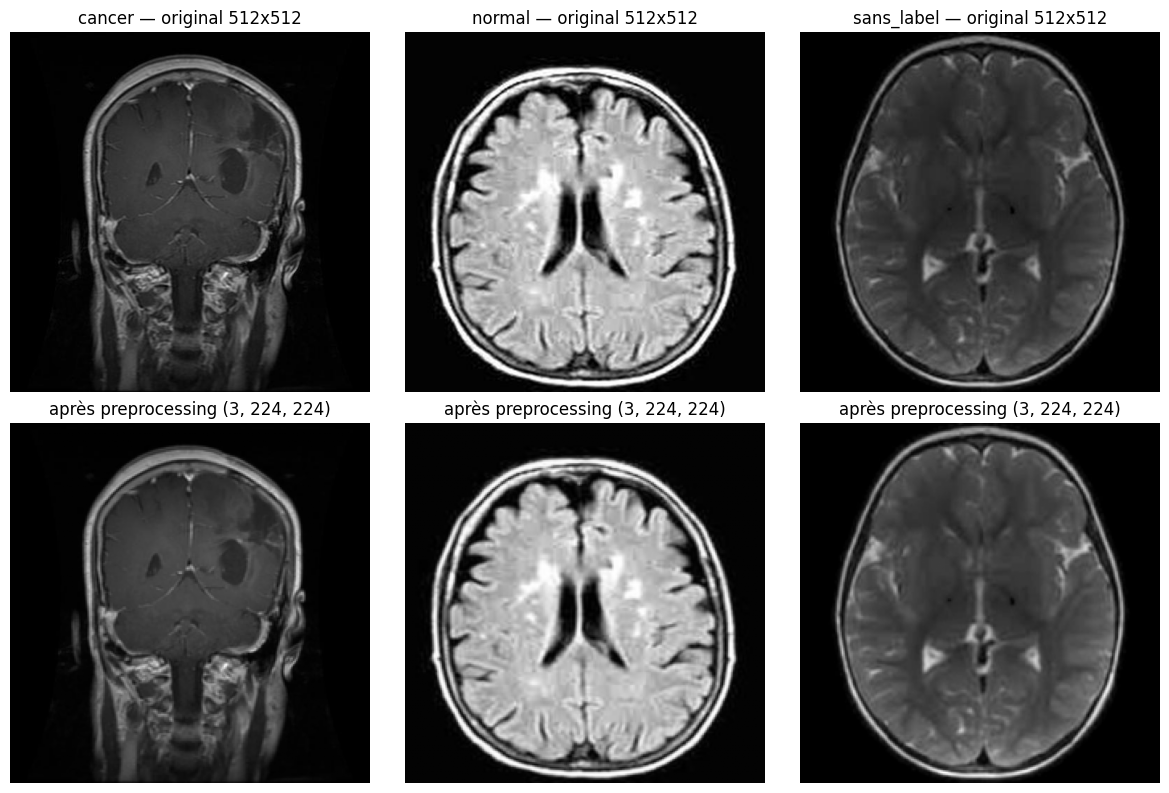

In [12]:
sample = df_clean.groupby("groupe").sample(1, random_state=0)

fig, axes = plt.subplots(2, len(sample), figsize=(4 * len(sample), 8))
for col, (_, row) in enumerate(sample.iterrows()):
    tensor = preprocess(Image.open(row["path"]))
    # Annule la normalisation sur le premier canal (les 3 sont identiques) pour afficher l'image
    displayed = tensor[0] * IMAGENET_STD[0] + IMAGENET_MEAN[0]

    axes[0, col].imshow(Image.open(row["path"]), cmap="gray")
    axes[0, col].set_title(f"{row['groupe']} — original 512x512")
    axes[1, col].imshow(displayed, cmap="gray")
    axes[1, col].set_title(f"après preprocessing {tuple(tensor.shape)}")
    for ax in axes[:, col]:
        ax.axis("off")
plt.tight_layout()
plt.show()

### 2.3 Chargement du modèle

On charge ResNet50 avec ses poids ImageNet, puis :
- on remplace sa dernière couche (`fc`, qui classait les 1 000 catégories d'ImageNet) par une **identité** : le réseau renvoie alors directement le vecteur de 2 048 valeurs issu de la couche `avgpool` ;
- on **gèle** tous les poids (`requires_grad = False`) : aucun paramètre ne sera modifié ;
- on passe en mode **évaluation** (`eval()`), pour que la batch normalization utilise ses statistiques mémorisées plutôt que celles du lot en cours.

Le calcul se fait sur le GPU s'il y en a un : `mps` sur Mac, `cuda` sur Colab, sinon le CPU.

In [13]:
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = torch.nn.Identity()          # on retire la couche de classification ImageNet
for param in model.parameters():
    param.requires_grad = False         # couches gelées
model = model.eval().to(device)

print(f"Calcul sur : {device}")

Calcul sur : mps


### 2.4 Extraction des embeddings sur deux couches

On extrait les features à **deux profondeurs** du réseau, pour les comparer au clustering :

| Couche | Taille | Ce qu'elle capte |
| --- | --- | --- |
| `avgpool` (sortie finale) | 2 048 | Des représentations de haut niveau, les plus spécialisées pour les objets d'ImageNet |
| `layer3` (intermédiaire) | 1 024 | Des textures et des motifs, plus génériques, qui se transfèrent parfois mieux vers un domaine éloigné comme l'IRM |

La sortie de `layer3` est une carte de 1 024 × 14 × 14 : on en fait la moyenne spatiale pour obtenir un vecteur de 1 024 valeurs. On la récupère avec un *hook*, une fonction appelée automatiquement quand les données traversent la couche : les deux embeddings sortent donc du même passage dans le réseau.

Les images sont traitées par lots de 32, sans calcul de gradient (`torch.no_grad()`), puisqu'on n'entraîne rien.

In [14]:
layer3_output = {}

def save_layer3(module, inputs, output):
    """Hook : moyenne spatiale de la sortie de layer3, (batch, 1024, 14, 14) -> (batch, 1024)."""
    layer3_output["features"] = output.mean(dim=(2, 3))

hook = model.layer3.register_forward_hook(save_layer3)

BATCH_SIZE = 32
paths = df_clean["path"].tolist()
feats_avgpool, feats_layer3 = [], []

with torch.no_grad():
    for start in range(0, len(paths), BATCH_SIZE):
        batch = torch.stack([preprocess(Image.open(p)) for p in paths[start:start + BATCH_SIZE]])
        feats_avgpool.append(model(batch.to(device)).cpu())      # sortie avgpool (2048)
        feats_layer3.append(layer3_output["features"].cpu())     # sortie layer3 (1024), via le hook

hook.remove()  # on retire le hook pour ne pas le cumuler si la cellule est relancée

emb_avgpool = torch.cat(feats_avgpool).numpy()
emb_layer3 = torch.cat(feats_layer3).numpy()

print(f"avgpool : {emb_avgpool.shape}")
print(f"layer3  : {emb_layer3.shape}")

avgpool : (1410, 2048)
layer3  : (1410, 1024)


### 2.5 Sauvegarde

Les embeddings sont sauvegardés au format `.npy`. La ligne *i* de chaque fichier correspond à la ligne *i* de `inventaire_images.csv` : c'est ce qui permet de retrouver l'image et son label à partir d'un embedding.

In [15]:
assert len(emb_avgpool) == len(emb_layer3) == len(inventaire)
assert np.isfinite(emb_avgpool).all() and np.isfinite(emb_layer3).all()

np.save(OUTPUT_DIR / "emb_resnet50_avgpool.npy", emb_avgpool)
np.save(OUTPUT_DIR / "emb_resnet50_layer3.npy", emb_layer3)

print("Embeddings sauvegardés dans", OUTPUT_DIR)

Embeddings sauvegardés dans ../outputs


### 2.6 Recherche de quasi-doublons

L'empreinte MD5 ne repère que les fichiers strictement identiques. Une image recadrée, recompressée ou légèrement éclaircie a une empreinte différente, mais un embedding presque identique.

On calcule la **similarité cosinus** entre tous les couples d'embeddings `avgpool`. Elle vaut 1 quand deux vecteurs pointent exactement dans la même direction. Les couples les plus proches sont affichés côte à côte pour juger à l'œil s'il s'agit de la même image.

In [16]:
from sklearn.metrics.pairwise import cosine_similarity

sim = cosine_similarity(emb_avgpool)
i, j = np.triu_indices_from(sim, k=1)   # chaque couple une seule fois, sans la diagonale
pairs = pd.DataFrame({"i": i, "j": j, "similarite": sim[i, j]})
pairs["groupe_i"] = df_clean["groupe"].values[pairs["i"]]
pairs["groupe_j"] = df_clean["groupe"].values[pairs["j"]]
pairs = pairs.sort_values("similarite", ascending=False).reset_index(drop=True)

for seuil in [0.99, 0.98, 0.97, 0.95]:
    above = pairs[pairs["similarite"] >= seuil]
    cross = (above["groupe_i"] != above["groupe_j"]).sum()
    print(f"similarité >= {seuil} : {len(above):4d} couples, dont {cross} entre groupes différents")

pairs.head(10)

similarité >= 0.99 :   11 couples, dont 1 entre groupes différents
similarité >= 0.98 :   30 couples, dont 3 entre groupes différents
similarité >= 0.97 :   46 couples, dont 4 entre groupes différents
similarité >= 0.95 :  119 couples, dont 19 entre groupes différents


,i,j,similarite,groupe_i,groupe_j
0,357,1234,0.995842,sans_label,sans_label
1,506,690,0.995631,sans_label,sans_label
2,1122,1381,0.994901,sans_label,sans_label
3,133,402,0.992677,sans_label,sans_label
4,155,458,0.991999,sans_label,sans_label
5,282,334,0.991777,sans_label,sans_label
6,69,334,0.991391,normal,sans_label
7,517,1185,0.991112,sans_label,sans_label
8,195,1011,0.991094,sans_label,sans_label
9,493,1241,0.990738,sans_label,sans_label


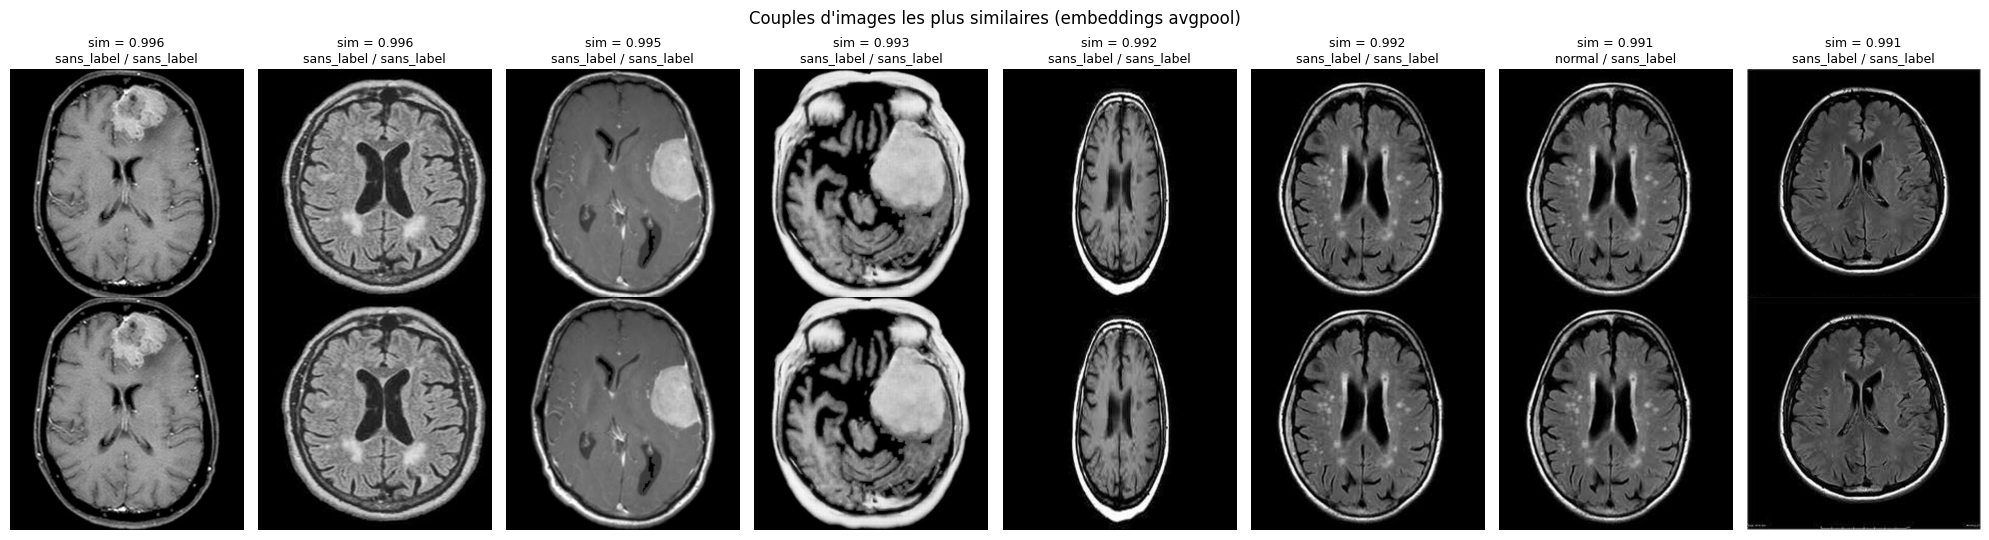

In [17]:
N_PAIRS = 8
fig, axes = plt.subplots(2, N_PAIRS, figsize=(2.5 * N_PAIRS, 5.5))
for k, row in pairs.head(N_PAIRS).iterrows():
    for r, idx in enumerate([row["i"], row["j"]]):
        axes[r, k].imshow(Image.open(df_clean.loc[idx, "path"]), cmap="gray")
        axes[r, k].axis("off")
    # Un seul titre par couple : similarité et groupes des deux images
    axes[0, k].set_title(f"sim = {row['similarite']:.3f}\n{row['groupe_i']} / {row['groupe_j']}", fontsize=9)
plt.suptitle("Couples d'images les plus similaires (embeddings avgpool)")
plt.tight_layout()
plt.show()

**Lecture des résultats.** Les couples au-dessus de 0,99 sont la même image recompressée. En dessous, on trouve aussi des **copies transformées** : la même coupe éclaircie, recadrée ou zoomée, parfois reconnaissable à un même filigrane. L'écart de pixels ne permet pas de les repérer, mais leur similarité d'embedding reste autour de 0,95 à 0,97. Sous 0,95, les couples sont en majorité des images différentes qui se ressemblent (même plan de coupe, même séquence).

Deux problèmes en découlent :
- **Fuite de données** : jusqu'à 19 images sans label sont des quasi-copies d'images labellisées.
- **Doublons dans le jeu fort** : 4 couples d'images `normal` sont des quasi-copies. À l'étape 4, une copie pourrait finir dans le train et l'autre dans le test, ce qui gonflerait les scores.

### 2.7 Retrait des quasi-doublons

On applique la même règle qu'au dédoublonnage MD5, avec un critère de similarité à la place de l'empreinte :

- **Seuil : 0,95.** C'est un choix prudent. Une fuite fausserait toute la comparaison entre supervisé et semi-supervisé, qui est le cœur du projet, alors que perdre environ 7 % des images sans label coûte peu. La contrepartie : quelques images seulement ressemblantes sont retirées aussi.
- **Priorité aux images labellisées** : on passe en revue les images labellisées d'abord, puis les images sans label. Chaque image est conservée seulement si elle n'est pas trop proche d'une image déjà conservée.

| Seuil (estimation préalable) | Fuites vers les labellisés | Images sans label retirées |
| --- | --- | --- |
| 0,99 | 1 | 9 |
| 0,97 | 4 | 37 |
| **0,95** | **19** | **98** |

À l'issue de cette section, l'inventaire et les deux fichiers d'embeddings sont **réécrits dans leur version filtrée**. Ce sont eux qui servent de référence pour la suite.

In [18]:
SEUIL_QUASI_DOUBLON = 0.95

# Ordre de passage : images labellisées d'abord (False < True), pour qu'elles priment sur leurs copies
order = np.argsort(df_clean["subset"].ne("avec_labels").values, kind="stable")

kept = []
for idx in order:
    # On écarte l'image si elle est trop proche d'une image déjà conservée
    if kept and sim[idx, kept].max() >= SEUIL_QUASI_DOUBLON:
        continue
    kept.append(idx)

keep_mask = np.zeros(len(df_clean), dtype=bool)
keep_mask[kept] = True

pd.DataFrame({
    "avant": df_clean["groupe"].value_counts(),
    "après": df_clean.loc[keep_mask, "groupe"].value_counts(),
}).assign(retirées=lambda t: t["avant"] - t["après"])

,avant,après,retirées
groupe,,,
sans_label,1311,1214,97
cancer,50,50,0
normal,49,46,3


In [19]:
# Filtrage cohérent du DataFrame, de l'inventaire et des deux jeux d'embeddings (mêmes lignes partout)
df_clean = df_clean[keep_mask].reset_index(drop=True)
inventaire = inventaire[keep_mask].reset_index(drop=True)
emb_avgpool = emb_avgpool[keep_mask]
emb_layer3 = emb_layer3[keep_mask]

# Vérification : plus aucun couple d'images au-dessus du seuil
check = cosine_similarity(emb_avgpool)
np.fill_diagonal(check, 0)
assert check.max() < SEUIL_QUASI_DOUBLON

# Sauvegarde des versions finales (écrase les fichiers précédents)
inventaire.to_csv(OUTPUT_DIR / "inventaire_images.csv", index=False)
np.save(OUTPUT_DIR / "emb_resnet50_avgpool.npy", emb_avgpool)
np.save(OUTPUT_DIR / "emb_resnet50_layer3.npy", emb_layer3)

print(f"Similarité maximale restante : {check.max():.4f}")
print(f"Jeu final : {len(df_clean)} images | avgpool {emb_avgpool.shape} | layer3 {emb_layer3.shape}")

Similarité maximale restante : 0.9499
Jeu final : 1310 images | avgpool (1310, 2048) | layer3 (1310, 1024)


### 2.8 Observations

**Preprocessing et extraction**
- Le preprocessing ne déforme pas les images : on passe d'un carré de 512 à un carré de 224. La conversion en gris sur 3 canaux efface au passage les bandeaux bleus des captures d'écran.
- L'extraction ne prend que quelques secondes sur le GPU d'un Mac (MPS) : Colab n'est pas nécessaire pour cette étape, puisque rien n'est entraîné.
- On dispose de deux représentations de chaque image, `avgpool` (2 048 valeurs) et `layer3` (1 024 valeurs). Elles seront comparées au clustering.

**Quasi-doublons**
- Les embeddings ont révélé des doublons que le MD5 ne pouvait pas détecter : des **copies transformées** d'une même image (recompressée, éclaircie, recadrée).
- Au seuil de similarité de 0,95, on retire 97 images sans label et 3 images normales. Cela élimine les fuites entre jeu faible et jeu fort, ainsi que les doublons internes au jeu fort.

**Jeu final : 1 310 images**

| Groupe | Images |
| --- | --- |
| cancer | 50 |
| normal | 46 |
| sans label | 1 214 |

Au total, le nettoyage a ramené les 1 506 fichiers d'origine à 1 310 images réellement distinctes, soit **13 % de redondance**.

**Ce que ça dit du jeu de données**
- Filigranes de sites web, captures d'écran de visionneuse, copies transformées, séquences hétérogènes : le jeu semble **compilé à partir de sources variées**, pas issu d'un protocole d'acquisition unique.
- C'est un enseignement pour le passage à l'échelle à 4 millions d'images : l'étape de **contrôle qualité et de dédoublonnage** doit faire partie du pipeline, sinon les métriques mesurées seront trompeuses.
- Le jeu fort ne compte plus que 96 images : le jeu de test de l'étape 4 sera petit, et les métriques devront être lues avec prudence.

**Pour l'étape 3**
- Standardiser les embeddings avant la PCA, puisque les dimensions n'ont pas la même échelle.
- Comparer `avgpool` et `layer3`, en gardant en tête le biais de séquence observé à l'étape 1.

---

## Étape 3 — Réduction de dimension, clustering et labels faibles

L'idée : si les embeddings capturent la présence d'une tumeur, les images devraient se regrouper naturellement en deux ensembles, sains et tumoraux, **sans qu'on ait besoin de labels**. On cherche ces regroupements, on vérifie avec les labels des radiologues qu'ils ont un sens médical, puis on s'en sert pour étiqueter les images sans label. C'est la labellisation « faible ».

### 3.1 Découpage train / test du jeu fort

On fixe **dès maintenant** le découpage du jeu fortement labellisé, qui servira aussi à l'étape 4 :
- le **train** (70 %) sert à évaluer les clusterings, à choisir le meilleur, et à décider quel cluster correspond au cancer ;
- le **test** (30 %) n'est **jamais utilisé** à l'étape 3. Il reste intact pour évaluer les modèles de l'étape 4 sur des images qu'aucune étape n'a vues.

Le découpage est **stratifié** : on garde la même proportion cancer / normal dans le train et dans le test. Il est enregistré dans l'inventaire (colonne `split_fort`).

In [20]:
from sklearn.model_selection import train_test_split

labeled_idx = df_clean.index[df_clean["subset"] == "avec_labels"]
train_idx, test_idx = train_test_split(
    labeled_idx,
    test_size=0.3,
    stratify=df_clean.loc[labeled_idx, "label"],   # même proportion cancer / normal des deux côtés
    random_state=42,
)

df_clean["split_fort"] = None
df_clean.loc[train_idx, "split_fort"] = "train"
df_clean.loc[test_idx, "split_fort"] = "test"

inventaire["split_fort"] = df_clean["split_fort"]
inventaire.to_csv(OUTPUT_DIR / "inventaire_images.csv", index=False)

pd.crosstab(df_clean["groupe"], df_clean["split_fort"].fillna("-"), margins=True)

split_fort,-,test,train,All
groupe,,,,
cancer,0,15,35,50
normal,0,14,32,46
sans_label,1214,0,0,1214
All,1214,29,67,1310


### 3.2 Standardisation

Chaque dimension d'un embedding a sa propre échelle. Sans standardisation, les dimensions aux grandes valeurs domineraient les calculs de distance du clustering et de la PCA. On ramène donc chaque dimension à une moyenne de 0 et un écart-type de 1.

La standardisation est ajustée sur toutes les images, sans utiliser aucun label.

In [21]:
from sklearn.preprocessing import StandardScaler

embeddings = {"avgpool": emb_avgpool, "layer3": emb_layer3}
scaled = {name: StandardScaler().fit_transform(emb) for name, emb in embeddings.items()}

for name, X in scaled.items():
    print(f"{name:8s} {X.shape} | moyenne {X.mean():.2f} | écart-type {X.std():.2f}")

avgpool  (1310, 2048) | moyenne -0.00 | écart-type 1.00
layer3   (1310, 1024) | moyenne -0.00 | écart-type 1.00


### 3.3 Réduction de dimension par PCA

Le clustering fonctionne mal en très grande dimension : avec 2 048 dimensions, toutes les distances entre points finissent par se ressembler (c'est le *fléau de la dimension*). On réduit donc les embeddings avec une **PCA**, qui garde les directions portant le plus de variance.

**Combien de composantes garder ?** On retient le nombre nécessaire pour conserver **80 % de la variance**. C'est un critère explicite, plutôt qu'un chiffre rond choisi à la main : on accepte de perdre 20 % de l'information, considérée comme du détail ou du bruit. Le nombre de composantes qui en découle dépend de la couche : plus l'information est diffuse, plus il en faut.

La section 3.6 vérifiera ensuite si ce choix a vraiment un effet sur la qualité du clustering.

In [22]:
from sklearn.decomposition import PCA

VARIANCE_CIBLE = 0.80

# On ajuste une PCA allant jusqu'à 90 % de variance : les composantes étant ordonnées
# par importance, on pourra ensuite tronquer à n'importe quelle taille sans tout recalculer.
pca_models = {name: PCA(n_components=0.90, random_state=42).fit(X) for name, X in scaled.items()}
projections = {name: pca.transform(scaled[name]) for name, pca in pca_models.items()}

n_composantes = {}
for name, pca in pca_models.items():
    cum_var = np.cumsum(pca.explained_variance_ratio_)
    n_composantes[name] = int(np.searchsorted(cum_var, VARIANCE_CIBLE) + 1)

# Embeddings réduits utilisés par défaut pour le clustering
reduced = {name: proj[:, :n_composantes[name]] for name, proj in projections.items()}

pd.DataFrame({
    "features au départ": {name: X.shape[1] for name, X in scaled.items()},
    "composantes pour 80 %": n_composantes,
    "variance conservée": {name: f"{np.cumsum(pca.explained_variance_ratio_)[n_composantes[name] - 1]:.0%}"
                           for name, pca in pca_models.items()},
})

,features au départ,composantes pour 80 %,variance conservée
avgpool,2048,296,80%
layer3,1024,85,80%


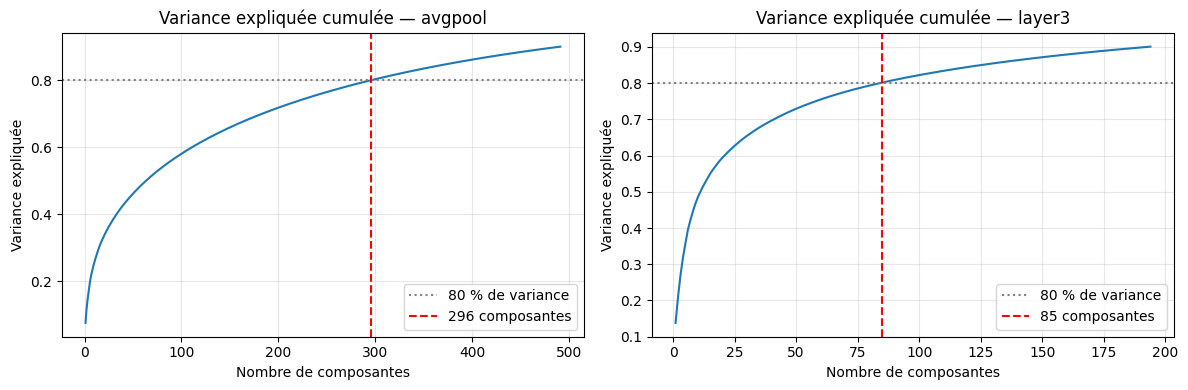

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, pca) in zip(axes, pca_models.items()):
    cum_var = np.cumsum(pca.explained_variance_ratio_)
    ax.plot(np.arange(1, len(cum_var) + 1), cum_var)
    ax.axhline(VARIANCE_CIBLE, color="grey", linestyle=":", label="80 % de variance")
    ax.axvline(n_composantes[name], color="red", linestyle="--",
               label=f"{n_composantes[name]} composantes")
    ax.set_title(f"Variance expliquée cumulée — {name}")
    ax.set_xlabel("Nombre de composantes")
    ax.set_ylabel("Variance expliquée")
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

On visualise les images sur les **deux premières** composantes de la PCA, en colorant les images labellisées. Si les deux classes se séparaient nettement ici, le clustering serait facile.

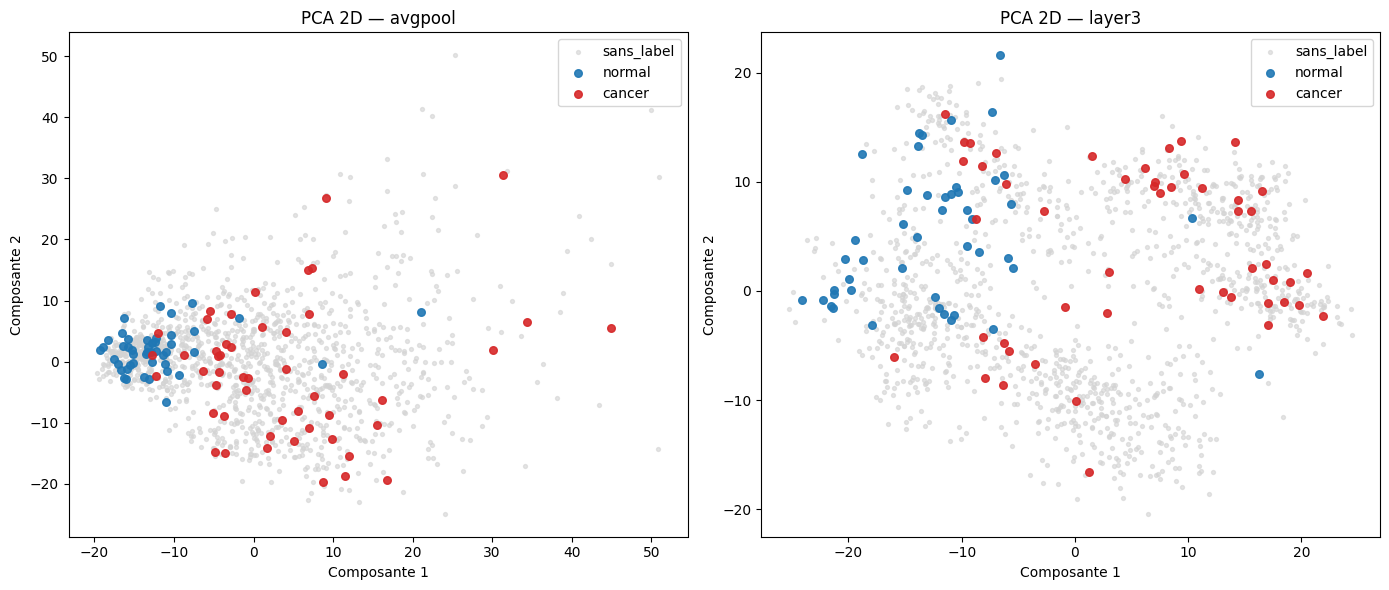

In [24]:
COLORS = {"sans_label": "lightgrey", "normal": "tab:blue", "cancer": "tab:red"}

def plot_groups(ax, coords, title):
    """Nuage de points 2D, coloré par groupe (images sans label en fond, en gris)."""
    for groupe in ["sans_label", "normal", "cancer"]:
        mask = (df_clean["groupe"] == groupe).values
        ax.scatter(coords[mask, 0], coords[mask, 1], c=COLORS[groupe], label=groupe,
                   s=8 if groupe == "sans_label" else 30, alpha=0.6 if groupe == "sans_label" else 0.9)
    ax.set_title(title)
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, proj) in zip(axes, projections.items()):
    plot_groups(ax, proj[:, :2], f"PCA 2D — {name}")
    ax.set_xlabel("Composante 1")
    ax.set_ylabel("Composante 2")
plt.tight_layout()
plt.show()

### 3.4 Visualisation par t-SNE

La PCA est une projection **linéaire** : elle peut écraser des structures plus complexes. Le **t-SNE** est une méthode non linéaire qui cherche à préserver les voisinages : deux images proches dans l'espace des embeddings restent proches sur le graphique.

Attention : le t-SNE sert **uniquement à la visualisation**. Il déforme les distances globales (la taille des amas et l'écart entre eux n'ont pas de sens), donc on ne fait pas de clustering dessus. On l'applique sur les composantes de la PCA, ce qui est la pratique courante.

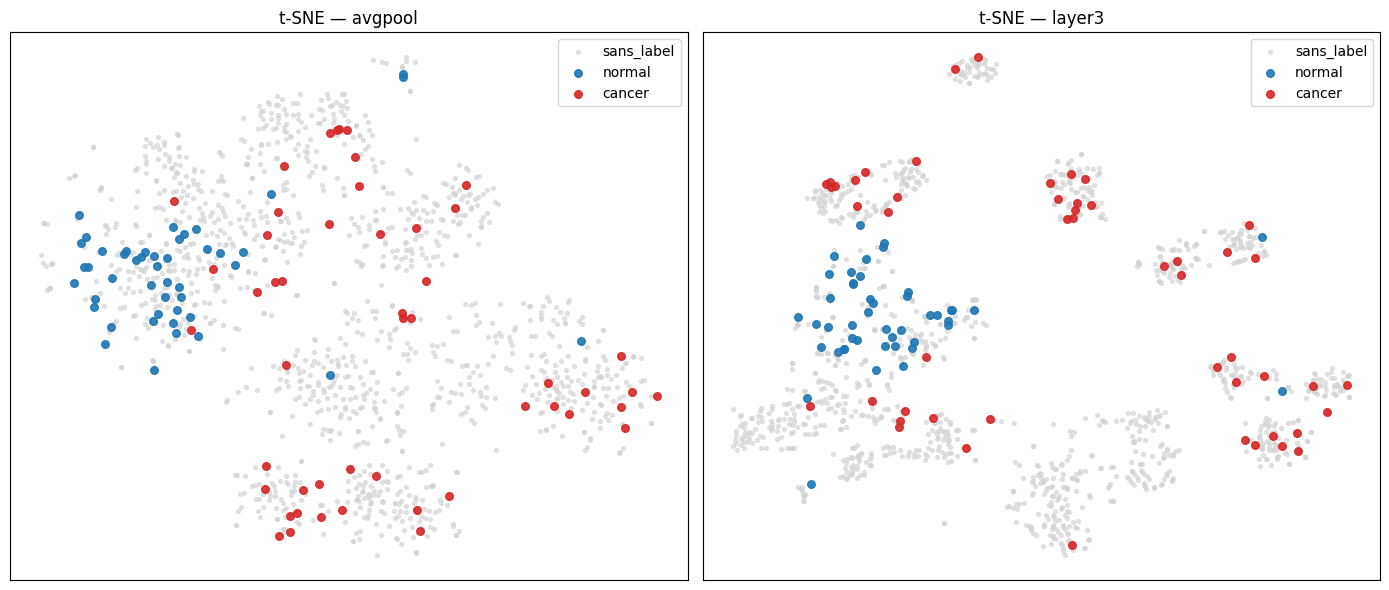

In [25]:
from sklearn.manifold import TSNE

tsne = {name: TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(Z)
        for name, Z in reduced.items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, T) in zip(axes, tsne.items()):
    plot_groups(ax, T, f"t-SNE — {name}")
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

### 3.5 Clustering : trois algorithmes à 2 groupes

On teste trois familles d'algorithmes, chacune avec une autre définition de ce qu'est un « groupe ». DBSCAN, qui fonctionne sur un principe différent et ne permet pas de fixer le nombre de groupes, fait l'objet de la section 3.7.

| Algorithme | Principe |
| --- | --- |
| **K-Means** | Chaque point rejoint le centre le plus proche ; les centres sont recalculés jusqu'à stabilité. Il suppose des groupes sphériques de tailles comparables. |
| **CAH (Ward)** | Classification ascendante hiérarchique : on part d'un point par groupe et on fusionne à chaque étape les deux groupes dont l'union augmente le moins la variance interne. |
| **Mélange gaussien** | On modélise les données comme un mélange de 2 lois normales. Chaque point reçoit une probabilité d'appartenance, et les groupes peuvent être allongés. |

> **Choix technique.** Le mélange gaussien est utilisé en **covariance diagonale**. En covariance complète, il doit estimer toutes les corrélations entre dimensions, soit environ 44 000 paramètres par groupe à 296 dimensions, pour seulement 1 310 images : le modèle devient instable. La version diagonale suppose les dimensions indépendantes et n'estime qu'une variance par dimension.

**Les deux mesures d'évaluation :**

- **ARI** (*Adjusted Rand Index*) : il mesure l'accord entre les clusters et les **vrais labels** des radiologues, calculé sur les images du **train** du jeu fort. Il vaut 1 si les clusters reproduisent parfaitement les labels, environ 0 pour un regroupement au hasard, et il peut être négatif. Il ne dépend pas du numéro attribué aux clusters. C'est la vérification recommandée : confronter le clustering à des images labellisées historiquement.
- **Silhouette** : elle mesure la qualité **interne** des clusters, sans aucun label. Pour chaque point, on compare la distance moyenne à son propre groupe et au groupe voisin. Elle va de -1 à 1 : plus elle est élevée, plus les groupes sont compacts et bien séparés.

Une bonne silhouette avec un ARI faible signifierait que les images se regroupent bien… mais selon un autre critère que la tumeur.

In [26]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, silhouette_score

train_mask = (df_clean["split_fort"] == "train").values
y_train = df_clean.loc[train_mask, "label"].values

def run_clusterings(Z):
    """Applique les 3 algorithmes à 2 groupes sur les embeddings réduits."""
    return {
        "K-Means": KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(Z),
        "CAH (Ward)": AgglomerativeClustering(n_clusters=2, linkage="ward").fit_predict(Z),
        "Mélange gaussien": GaussianMixture(n_components=2, covariance_type="diag",
                                            random_state=42).fit_predict(Z),
    }

rows = []
for name, Z in reduced.items():
    for algo, labels in run_clusterings(Z).items():
        rows.append({
            "couche": name,
            "composantes": Z.shape[1],
            "algorithme": algo,
            "ARI (train fort)": adjusted_rand_score(y_train, labels[train_mask]),
            "silhouette": silhouette_score(Z, labels),
            "taille des groupes": np.bincount(labels).tolist(),
        })

pd.DataFrame(rows).sort_values("ARI (train fort)", ascending=False).round(3).reset_index(drop=True)

,couche,composantes,algorithme,ARI (train fort),silhouette,taille des groupes
0,layer3,85,K-Means,0.443,0.138,"[761, 549]"
1,avgpool,296,CAH (Ward),0.443,0.046,"[786, 524]"
2,avgpool,296,K-Means,0.295,0.118,"[755, 555]"
3,layer3,85,CAH (Ward),0.263,0.115,"[927, 383]"
4,layer3,85,Mélange gaussien,0.231,0.083,"[382, 928]"
5,avgpool,296,Mélange gaussien,0.067,0.124,"[753, 557]"


### 3.6 L'ARI dépend-il du nombre de composantes ?

Le choix de 80 % de variance reste un choix. On le met donc à l'épreuve : on refait tourner les trois algorithmes sur des PCA de tailles croissantes, de 2 composantes jusqu'à 90 % de variance, et on regarde comment l'ARI évolue.

Deux effets s'opposent :
- **trop peu de composantes** : on perd de l'information utile pour distinguer les classes ;
- **trop de composantes** : on réintroduit du bruit et le fléau de la dimension, qui dilue les distances.

Comme les composantes sont ordonnées par importance, tronquer la projection revient exactement à refaire une PCA plus petite : aucun recalcul n'est nécessaire.

In [27]:
# Tailles testées : quelques valeurs rondes, puis les seuils de variance
tailles = {name: sorted({2, 10, 20, 50, n_composantes[name], proj.shape[1]})
           for name, proj in projections.items()}

rows = []
for name, proj in projections.items():
    cum_var = np.cumsum(pca_models[name].explained_variance_ratio_)
    for n in tailles[name]:
        Z = proj[:, :n]
        for algo, labels in run_clusterings(Z).items():
            rows.append({
                "couche": name,
                "composantes": n,
                "variance": cum_var[n - 1],
                "algorithme": algo,
                "ARI (train fort)": adjusted_rand_score(y_train, labels[train_mask]),
                "silhouette": silhouette_score(Z, labels),
            })

sweep = pd.DataFrame(rows)
sweep.pivot_table(index=["couche", "composantes", "variance"],
                  columns="algorithme", values="ARI (train fort)").round(3)

algorithme                    CAH (Ward)  K-Means  Mélange gaussien
couche  composantes variance                                       
avgpool 2           0.115272       0.152    0.295             0.620
        10          0.255442       0.443    0.295             0.528
        20          0.335027       0.443    0.295            -0.000
        50          0.461553       0.484    0.295            -0.010
        296         0.800344       0.443    0.295             0.067
        491         0.900273       0.573    0.295             0.105
layer3  2           0.210020       0.329    0.365             0.403
        10          0.483912       0.403    0.443             0.573
        20          0.593837       0.443    0.443             0.365
        50          0.729113       0.329    0.443             0.203
        85          0.801319       0.263    0.443             0.231
        194         0.900469       0.329    0.443             0.150

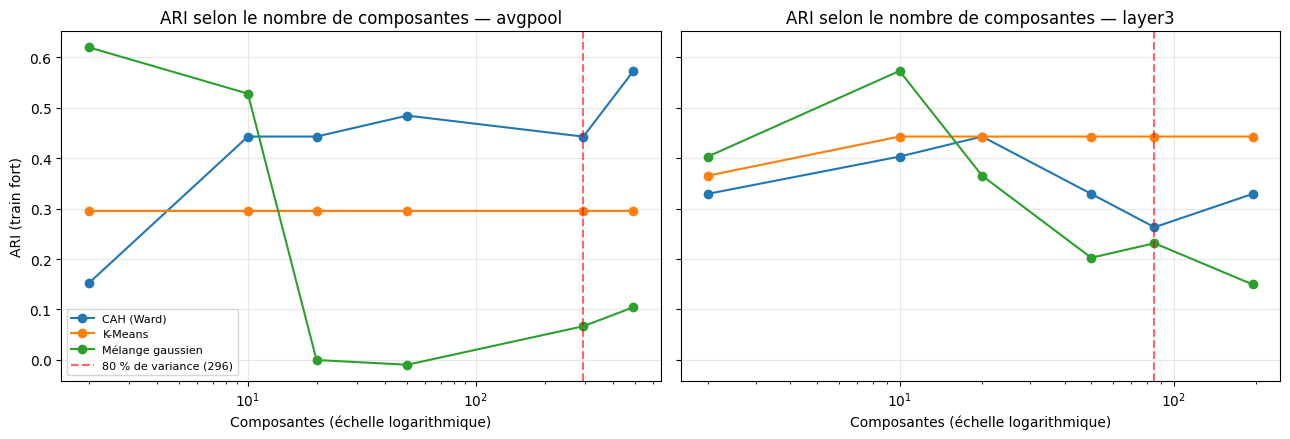

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, name in zip(axes, projections):
    sub = sweep[sweep["couche"] == name]
    for algo, grp in sub.groupby("algorithme"):
        ax.plot(grp["composantes"], grp["ARI (train fort)"], marker="o", label=algo)
    ax.axvline(n_composantes[name], color="red", linestyle="--", alpha=0.6,
               label=f"80 % de variance ({n_composantes[name]})")
    ax.set_xscale("log")
    ax.set_title(f"ARI selon le nombre de composantes — {name}")
    ax.set_xlabel("Composantes (échelle logarithmique)")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("ARI (train fort)")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

### 3.7 DBSCAN, plus en détail

DBSCAN raisonne autrement : un groupe est une **zone dense** de points, et les points isolés sont déclarés « bruit » (label `-1`). Il ne demande pas le nombre de groupes, mais deux autres paramètres :
- `min_samples` : le nombre de voisins requis pour qu'une zone soit considérée comme dense ;
- `eps` : le rayon dans lequel on compte ces voisins.

Comme `eps` est une distance, sa bonne valeur dépend complètement de la dimension et de l'échelle des données. On l'exprime donc en **percentile des distances au voisin le plus éloigné du groupe** : la distance de chaque point à son `min_samples`-ième voisin, qui est la méthode classique du « coude ».

On balaie une grille : tailles de PCA × `eps` × `min_samples`, et on regarde combien de groupes DBSCAN trouve, quelle part des images il déclare en bruit, et quel ARI il obtient.

In [29]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

rows = []
for name, proj in projections.items():
    for n in [2, 10, 50, n_composantes[name]]:
        Z = proj[:, :n]
        for min_samples in [5, 10, 20]:
            # Distances au min_samples-ième voisin : base du réglage de eps
            k_dist = NearestNeighbors(n_neighbors=min_samples).fit(Z).kneighbors(Z)[0][:, -1]
            for pct in [50, 70, 80, 90, 95]:
                labels = DBSCAN(eps=np.percentile(k_dist, pct), min_samples=min_samples).fit_predict(Z)
                n_clusters = len(set(labels) - {-1})
                rows.append({
                    "couche": name,
                    "composantes": n,
                    "min_samples": min_samples,
                    "percentile eps": pct,
                    "nb clusters": n_clusters,
                    "bruit": (labels == -1).mean(),
                    # Le bruit (-1) compte comme un groupe à part entière dans l'ARI
                    "ARI (train fort)": adjusted_rand_score(y_train, labels[train_mask]),
                })

dbscan_grid = pd.DataFrame(rows)
print(f"{len(dbscan_grid)} configurations testées")
print(f"Configurations trouvant exactement 2 groupes : {(dbscan_grid['nb clusters'] == 2).sum()}")

# Les 10 meilleures configurations au sens de l'ARI
dbscan_grid.sort_values("ARI (train fort)", ascending=False).head(10).round(3).reset_index(drop=True)

120 configurations testées
Configurations trouvant exactement 2 groupes : 10


,couche,composantes,min_samples,percentile eps,nb clusters,bruit,ARI (train fort)
0,layer3,85,20,50,3,0.312,0.382
1,layer3,10,10,50,10,0.329,0.363
2,layer3,85,10,50,6,0.362,0.361
3,layer3,50,10,50,7,0.341,0.361
4,layer3,10,20,50,8,0.285,0.361
5,layer3,10,10,70,7,0.182,0.360
6,layer3,50,20,50,5,0.308,0.338
7,layer3,10,5,50,13,0.378,0.331
8,layer3,10,20,70,4,0.153,0.277
9,layer3,50,10,70,3,0.192,0.268


In [30]:
# Vue d'ensemble : combien de groupes DBSCAN trouve-t-il selon la dimension et eps ?
dbscan_grid.pivot_table(index=["couche", "composantes"], columns=["min_samples", "percentile eps"],
                        values="nb clusters")

min_samples            5                           10                      \
percentile eps         50    70    80   90   95    50   70   80   90   95   
couche  composantes                                                         
avgpool 2            38.0  13.0  13.0  7.0  2.0   8.0  4.0  3.0  2.0  1.0   
        10            4.0   2.0   2.0  1.0  1.0   1.0  1.0  1.0  1.0  1.0   
        50            2.0   1.0   1.0  1.0  1.0   1.0  1.0  1.0  1.0  1.0   
        296           1.0   1.0   1.0  1.0  1.0   1.0  1.0  1.0  1.0  1.0   
layer3  2            37.0  13.0   4.0  5.0  3.0  10.0  3.0  2.0  1.0  1.0   
        10           13.0  13.0   9.0  5.0  1.0  10.0  7.0  4.0  1.0  1.0   
        50           20.0  11.0   8.0  4.0  2.0   7.0  3.0  1.0  1.0  1.0   
        85           18.0   8.0   4.0  2.0  2.0   6.0  2.0  1.0  1.0  1.0   

min_samples           20                      
percentile eps        50   70   80   90   95  
couche  composantes                           
avgpool 2            3.0  1.0  1.0  1.0  1.0  
        10           1.0  1.0  1.0  1.0  1.0  
        50           1.0  1.0  1.0  1.0  1.0  
        296          1.0  1.0  1.0  1.0  1.0  
layer3  2            3.0  3.0  1.0  1.0  1.0  
        10           8.0  4.0  1.0  1.0  1.0  
        50           5.0  1.0  1.0  1.0  1.0  
        85           3.0  1.0  1.0  1.0  1.0

### 3.8 Le meilleur clustering voit-il la tumeur ?

On retient la configuration (couche × nombre de composantes × algorithme) qui obtient le meilleur ARI **parmi celles qui conservent au moins 80 % de la variance**. Ce filtre est important : la section précédente a montré qu'une PCA à 2 composantes peut obtenir un ARI supérieur, mais elle ne garde que 12 % de l'information, ce qui rend le résultat fragile et difficile à défendre.

On regarde ensuite la configuration retenue sous trois angles :
1. la répartition des labels du train fort dans chaque cluster ;
2. les clusters sur le t-SNE, à côté des vrais labels ;
3. des images tirées au hasard dans chaque cluster, et leur luminosité moyenne, pour tester l'hypothèse de l'étape 1 : les clusters suivent-ils la tumeur, ou la séquence d'acquisition ?

In [31]:
# On ne retient que les configurations conservant au moins 80 % de la variance
eligibles = sweep[sweep["variance"] >= VARIANCE_CIBLE]
best = eligibles.sort_values("ARI (train fort)", ascending=False).iloc[0]
best_layer, best_n, best_algo = best["couche"], int(best["composantes"]), best["algorithme"]

Z_best = projections[best_layer][:, :best_n]
best_clusters = run_clusterings(Z_best)[best_algo]
df_clean["cluster"] = best_clusters

print(f"Meilleure configuration : {best_algo} sur {best_layer}, {best_n} composantes "
      f"({best['variance']:.0%} de variance) — ARI = {best['ARI (train fort)']:.3f}\n")

# Répartition des labels du train fort dans chaque cluster
pd.crosstab(df_clean.loc[train_mask, "cluster"], df_clean.loc[train_mask, "label"], margins=True)

Meilleure configuration : CAH (Ward) sur avgpool, 491 composantes (90% de variance) — ARI = 0.573



label,cancer,normal,All
cluster,,,
0,30,3,33
1,5,29,34
All,35,32,67


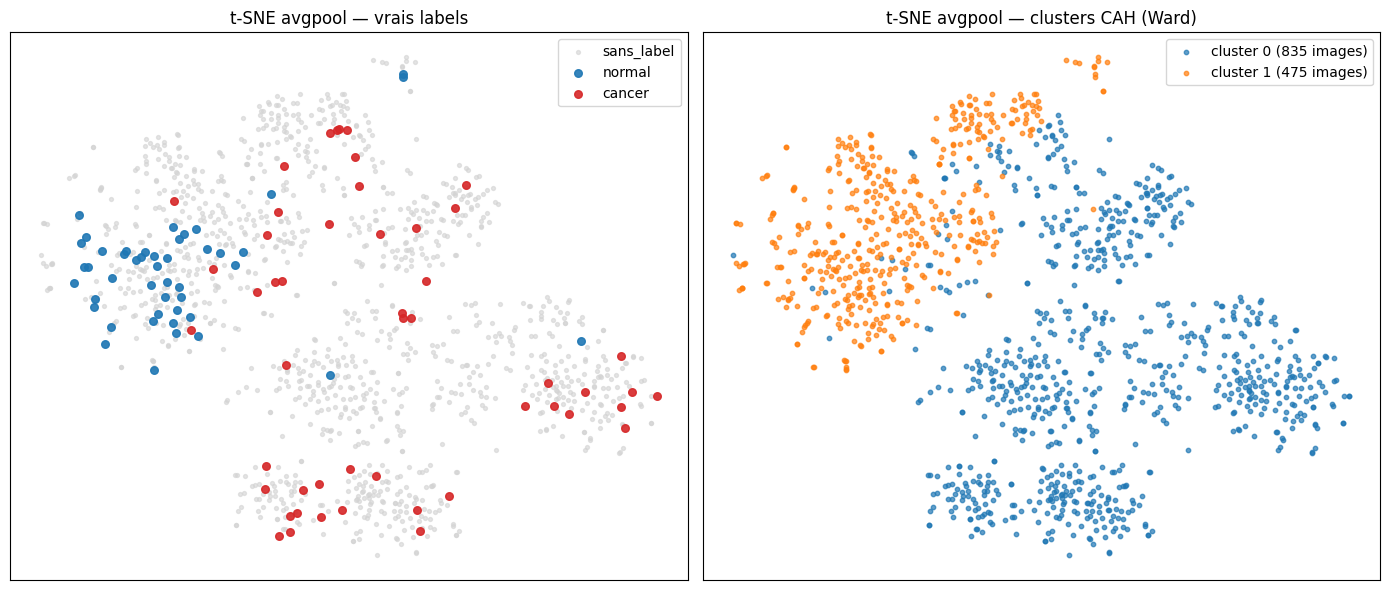

In [32]:
T = tsne[best_layer]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_groups(axes[0], T, f"t-SNE {best_layer} — vrais labels")

for c in sorted(set(best_clusters)):
    mask = best_clusters == c
    axes[1].scatter(T[mask, 0], T[mask, 1], s=10, alpha=0.7, label=f"cluster {c} ({mask.sum()} images)")
axes[1].set_title(f"t-SNE {best_layer} — clusters {best_algo}")
axes[1].legend()

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

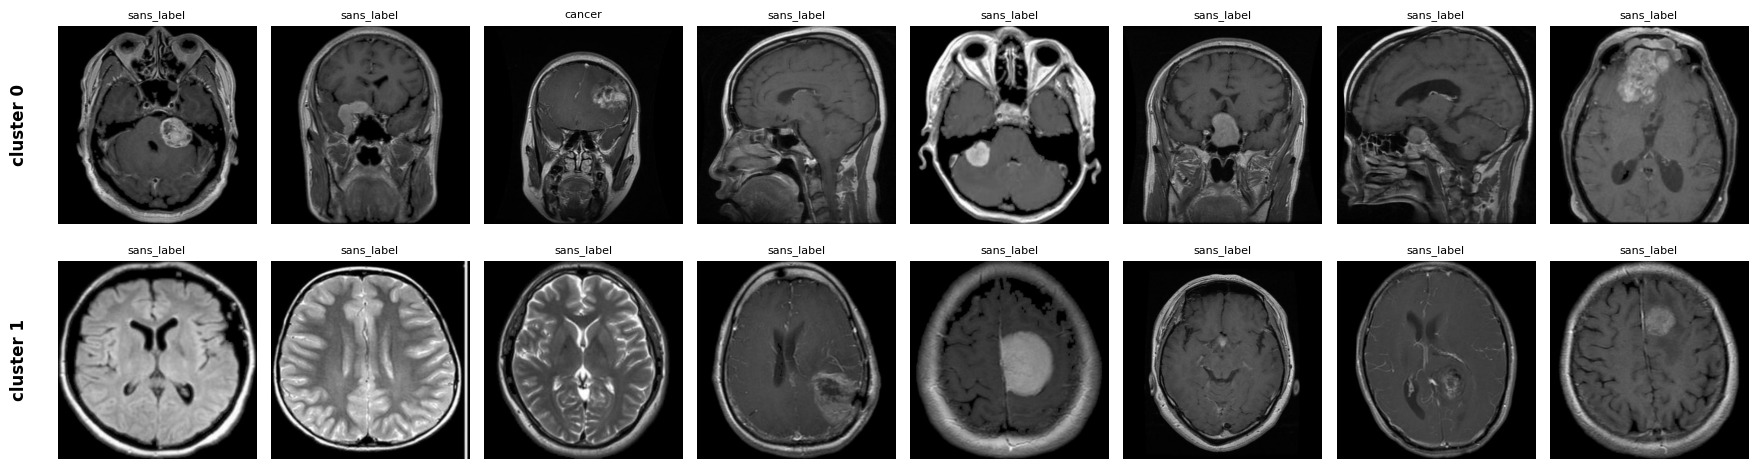

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,835.0,49.0,13.6,14.9,40.9,48.5,54.6,136.2
1,475.0,55.6,20.4,17.7,41.2,53.6,66.6,115.3


In [33]:
N_PER_CLUSTER = 8
cluster_ids = sorted(set(best_clusters))

fig, axes = plt.subplots(len(cluster_ids), N_PER_CLUSTER, figsize=(2.2 * N_PER_CLUSTER, 2.5 * len(cluster_ids)))
for row, c in enumerate(cluster_ids):
    sample = df_clean[df_clean["cluster"] == c].sample(N_PER_CLUSTER, random_state=0)
    for col, (_, r) in enumerate(sample.iterrows()):
        axes[row, col].imshow(Image.open(r["path"]), cmap="gray")
        axes[row, col].set_title(r["groupe"], fontsize=8)
        axes[row, col].axis("off")
    axes[row, 0].text(-0.15, 0.5, f"cluster {c}", transform=axes[row, 0].transAxes,
                      rotation=90, va="center", ha="right", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# Luminosité moyenne par cluster (hypothèse du biais de séquence)
df_clean.groupby("cluster")["mean_intensity"].describe().round(1)

### 3.9 Labels faibles

On transforme les clusters en labels :
1. chaque cluster reçoit la **classe majoritaire** des images du train fort qu'il contient ;
2. chaque image sans label reçoit la classe de son cluster.

Pour suivre les mêmes métriques que dans la suite du projet (accuracy, F1, AUC), il faut aussi un **score continu** : l'AUC évalue un classement, pas une décision binaire. On calcule un score de « cancer » à partir de la position de chaque image entre les deux centres de clusters : la distance au centre du cluster normal, moins la distance au centre du cluster cancer. Plus il est élevé, plus l'image est du côté cancer.

Ces métriques, calculées sur le train fort, donnent une **estimation de la qualité des labels faibles**. Elles sont un peu optimistes, puisque ces mêmes images ont servi à associer les clusters aux classes.

Les labels faibles sont sauvegardés dans un fichier **à part**, `labels_faibles.csv`, qui ne contient que des images sans label : ils ne sont jamais mélangés aux labels forts.

In [34]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# 1. Chaque cluster reçoit la classe majoritaire des images du train fort qu'il contient
train_labeled = df_clean[train_mask]
cluster_to_label = train_labeled.groupby("cluster")["label"].agg(lambda s: s.value_counts().idxmax()).to_dict()
print("Association cluster -> classe :", cluster_to_label)
df_clean["label_cluster"] = df_clean["cluster"].map(cluster_to_label)

# 2. Score continu de « cancer » : distance au centre normal - distance au centre cancer
centre = {lab: Z_best[df_clean["label_cluster"].values == lab].mean(axis=0) for lab in ["cancer", "normal"]}
df_clean["score_cancer"] = (np.linalg.norm(Z_best - centre["normal"], axis=1)
                            - np.linalg.norm(Z_best - centre["cancer"], axis=1))

# 3. Qualité estimée des labels faibles, sur le train fort (cancer = classe positive)
eval_df = df_clean[train_mask]
y_true = (eval_df["label"] == "cancer").astype(int)
y_pred = (eval_df["label_cluster"] == "cancer").astype(int)
pd.Series({
    "accuracy": accuracy_score(y_true, y_pred),
    "F1 (cancer)": f1_score(y_true, y_pred),
    "AUC": roc_auc_score(y_true, eval_df["score_cancer"]),
}, name="qualité des labels faibles (train fort)").round(3)

Association cluster -> classe : {0: 'cancer', 1: 'normal'}


accuracy       0.881
F1 (cancer)    0.882
AUC            0.933
Name: qualité des labels faibles (train fort), dtype: float64

In [35]:
# Sauvegarde des labels faibles : images sans label uniquement, dans un fichier séparé
weak = df_clean[df_clean["subset"] == "sans_label"].copy()
weak["path"] = weak["path"].apply(lambda p: p.relative_to(DATA_DIR).as_posix())
weak = weak.rename(columns={"label_cluster": "label_faible"})[["path", "label_faible", "score_cancer", "cluster"]]
weak.to_csv(OUTPUT_DIR / "labels_faibles.csv", index=False)

print(f"{len(weak)} labels faibles sauvegardés dans {OUTPUT_DIR / 'labels_faibles.csv'}")
weak["label_faible"].value_counts()

1214 labels faibles sauvegardés dans ../outputs/labels_faibles.csv


label_faible
cancer    789
normal    425
Name: count, dtype: int64

### 3.10 Observations

**Combien de composantes garder ?**
- Conserver 80 % de la variance demande **296 composantes** pour `avgpool` (sur 2 048) et **85** pour `layer3` (sur 1 024). L'information d'`avgpool` est nettement plus diffuse.
- Le balayage montre que **l'ARI n'augmente pas avec la variance conservée**. La courbe monte et descend : selon les directions gardées, le clustering capte tantôt un critère utile, tantôt un autre.
- Le meilleur ARI de tout le balayage est obtenu par un mélange gaussien sur **2 composantes** (ARI 0,620), qui ne conservent que 12 % de la variance. C'est un résultat intéressant, mais fragile : il repose sur très peu d'information.
- **Explication** : la PCA garde ce qui **varie le plus** entre les images, pas ce qui est **utile pour détecter une tumeur**. Or ce qui varie le plus ici, c'est le plan de coupe, la séquence et le contraste. Une tumeur n'occupe qu'une petite zone de l'image et pèse peu dans la variance totale.

**Configuration retenue**
- **CAH de Ward sur `avgpool`, 491 composantes (90 % de variance), ARI = 0,573.** C'est le meilleur ARI parmi les configurations conservant au moins 80 % de la variance.
- Sur le train fort, ce clustering place 30 cancers sur 35 dans le cluster 0 et 29 normaux sur 32 dans le cluster 1 : 8 erreurs sur 67 images.
- Pour situer : un ARI considéré comme bon se situe entre 0,70 et 0,80. Notre 0,573 traduit un accord réel mais imparfait, ce qui reste cohérent avec la petite taille du jeu labellisé.

**DBSCAN : démonstration par la grille**
- 120 configurations testées (2 couches × 4 tailles de PCA × 3 `min_samples` × 5 valeurs d'`eps`). **Seules 10 trouvent exactement 2 groupes.**
- Son meilleur ARI est de 0,382, obtenu avec 3 groupes et 31 % des images déclarées en bruit.
- Au-delà de 50 composantes, il ne trouve plus qu'**un seul groupe** quelle que soit la configuration : en grande dimension, toutes les distances se ressemblent et la notion de zone dense disparaît.
- Conclusion : les images ne forment pas deux amas denses séparés par du vide, mais un **continuum**. DBSCAN n'est pas adapté à ce problème, et cette fois c'est démontré sur une grille complète plutôt qu'affirmé.

**Qualité des labels faibles**
- Sur le train fort : accuracy 0,881, F1 (cancer) 0,882, AUC 0,933.
- Répartition obtenue sur les images sans label : 789 cancer et 425 normal.
- Ces chiffres sont **optimistes** : ces mêmes images ont servi à associer les clusters aux classes, et le jeu labellisé est lui-même biaisé.

**Le clustering voit-il la tumeur ? En partie seulement**
- En regardant les images de chaque cluster, la séparation suit surtout le **plan de coupe** (coupes coronales et sagittales d'un côté, axiales de l'autre) et le **type de séquence**.
- Les deux clusters contiennent des images avec des tumeurs bien visibles.
- L'écart de luminosité moyenne entre clusters reste modéré (49 contre 55,6) : ce n'est pas la luminosité seule qui guide le regroupement.
- Comme les images `cancer` du jeu labellisé sont majoritairement d'une certaine orientation et d'une certaine séquence, un clustering qui sépare les orientations obtient mécaniquement un bon ARI. **Le score est donc flatté par ce biais.**

**Conséquences pour l'étape 4**
- Les labels faibles restent utiles pour **préentraîner** un CNN, mais ils transportent ce biais d'orientation.
- Piste à tester : appliquer des **rotations et des retournements** aux images pendant l'entraînement, pour empêcher le CNN de se fier à l'orientation.
- Autre piste, inspirée de la pseudo-labellisation : ne garder que les labels faibles les plus sûrs, c'est-à-dire les images dont le `score_cancer` est loin de la frontière entre les deux clusters.
- Le jeu de test fort (29 images) n'a été utilisé nulle part : il reste une évaluation honnête pour l'étape 4.